Assignment 3 

t8220103 Βασίλειος Μυλωνάς 

In [ ]:
import pandas as pd 


In [2]:
choices = pd.read_csv('https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main/c13k_selections.csv')

In [19]:
choices.head()

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185


In [3]:
problems = pd.read_json("https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main/c13k_problems.json", orient='index')

In [27]:
problems

,B,A
0,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...
14563,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


In [4]:
choices_raw = choices.copy()

In [5]:
problems_raw = problems.copy()

## MODEL 1: LINEAR REGRESSION

After reading the papers, trying to understand where the dataset came from and what features should i use , i understood that this dataset is randomly selected , hence why they are different block numbers for different problems. I am not going to try to exactly analyze what cognitive behaviours are present in the dataset,nor will i try to directly rebuild the BEAST model, but what i will try is feature engineer features that somewhat represent the distinct anomalies with the sensitivity to expected return and the 4 tendecies:pessimism, bias toward equal weighting, sensitivity to payoff sign, and an effort
to minimize the probability of immediate regret

Lets first merge the choices and problems into one dataframe 

In [6]:
c13k_w_gambles = choices.join(problems, how="left")

In [31]:
c13k_w_gambles

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


In [7]:
feature_table = c13k_w_gambles.copy()

feature_table["EV_A"] = feature_table["pHa"] * feature_table["Ha"] + (1 - feature_table["pHa"]) * feature_table["La"]
feature_table["EV_B"] = feature_table["pHb"] * feature_table["Hb"] + (1 - feature_table["pHb"]) * feature_table["Lb"]
feature_table["EV_diff"] = feature_table["EV_B"] - feature_table["EV_A"]


In [8]:
feature_table["Range_A"] = (feature_table["Ha"] - feature_table["La"]).abs()
feature_table["Range_B"] = (feature_table["Hb"] - feature_table["Lb"]).abs()
feature_table["Range_diff"] = feature_table["Range_B"] - feature_table["Range_A"]


In [9]:
feature_table["Worst_A"] = feature_table[["Ha", "La"]].min(axis=1)
feature_table["Worst_B"] = feature_table[["Hb", "Lb"]].min(axis=1)
feature_table["Worst_diff"] = feature_table["Worst_B"] - feature_table["Worst_A"]


In [10]:
feature_table["Amb"] = feature_table["Amb"].astype(int)
feature_table["Feedback"] = feature_table["Feedback"].astype(int)
feature_table["Block"] = feature_table["Block"].astype(int)
feature_table["Corr"] = feature_table["Corr"].astype(int)
feature_table["Feedback_Block"] = feature_table["Feedback"] * feature_table["Block"]


In [23]:
feature_cols = [
    "EV_diff",
    "Range_diff",
    "Worst_diff",
    "Amb",
    "Feedback",
    "Block",
    "Feedback_Block",
    "Corr",
]

X = feature_table
y = feature_table["bRate"]


In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scale_cols = ["EV_diff", "Range_diff", "Worst_diff"]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X_scaled[scale_cols])

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_scaled, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = lr.predict(X_test)


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression MAE:  {mae:.4f}")
print(f"Linear Regression RMSE: {rmse:.4f}")
print(f"Linear Regression R²:   {r2:.4f}")


Linear Regression MAE:  0.1337
Linear Regression RMSE: 0.1643
Linear Regression R²:   0.4484


In [19]:
from sklearn.model_selection import cross_val_score

cv_mae = -cross_val_score(
    lr,
    X_scaled,
    y,
    scoring="neg_mean_absolute_error",
    cv=5
)

print(f"CV MAE: mean={cv_mae.mean():.4f}, std={cv_mae.std():.4f}")


CV MAE: mean=0.1332, std=0.0019


In [20]:
coef_table = (
    pd.Series(lr.coef_, index=X.columns)
      .sort_values(key=abs, ascending=False)
)

coef_table


EV_diff           0.125298
Worst_diff        0.069573
Amb               0.047099
Range_diff        0.032113
Corr              0.002382
Feedback_Block    0.002031
dtype: float64

In [21]:
results_linear = {
    "model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "CV_MAE_mean": cv_mae.mean(),
    "CV_MAE_std": cv_mae.std()
}


In [22]:
results_linear

{'model': 'Linear Regression',
 'MAE': 0.1336768183408819,
 'RMSE': np.float64(0.16433025633154477),
 'R2': 0.44840794727121114,
 'CV_MAE_mean': np.float64(0.13321764876787778),
 'CV_MAE_std': np.float64(0.0019435749849000292)}

I will stop here since "Human choice behavior contains strong nonlinearities and interactions that linear models cannot capture."

In [26]:
rf_features = [
    "EV_diff",
    "Range_diff",
    "Worst_diff",
    "EV_A",
    "EV_B",
    "Range_A",
    "Range_B",
    "Worst_A",
    "Worst_B",
    "Amb",
    "Feedback",
    "Block",
    "Feedback_Block",
    "Corr",
    "LotNumB",
    "LotShapeB",
]

X_rf = feature_table[rf_features]
y = feature_table["bRate"]


In [57]:
X_new = X_rf.copy()

In [58]:
X_new["A_all_gain"] = (X_new["Worst_A"] >= 0).astype(int)
X_new["B_all_gain"] = (X_new["Worst_B"] >= 0).astype(int)

X_new["A_mixed"] = ((X_new["Worst_A"] < 0) & (X_new["Range_A"] > 0)).astype(int)
X_new["B_mixed"] = ((X_new["Worst_B"] < 0) & (X_new["Range_B"] > 0)).astype(int)
X_new["pWorst_A"] = X_new["Worst_A"] * (1 - choices["pHa"])
X_new["pWorst_B"] = X_new["Worst_B"] * (1 - choices["pHb"])

X_new["pWorst_diff"] = X_new["pWorst_B"] - X_new["pWorst_A"]
X_new["A_dominates"] = (
    (X_new["EV_A"] > X_new["EV_B"]) &
    (X_new["Worst_A"] >= X_new["Worst_B"]) &
    (X_new["Range_A"] <= X_new["Range_B"])
).astype(int)

X_new["B_dominates"] = (
    (X_new["EV_B"] > X_new["EV_A"]) &
    (X_new["Worst_B"] >= X_new["Worst_A"]) &
    (X_new["Range_B"] <= X_new["Range_A"])
).astype(int)

X_new["EV_ratio"] = X_new["EV_B"] / (X_new["EV_A"].abs() + 1e-6)
X_new["Amb_EV_interaction"] = X_new["Amb"] * X_new["EV_diff"]
X_new["Certainty_A"] = (choices["pHa"] > 0.8).astype(int)
X_new["Certainty_B"] = (choices["pHb"] > 0.8).astype(int)

X_new["Certainty_diff"] = X_new["Certainty_B"] - X_new["Certainty_A"]
X_new["EV_diff_tanh"] = np.tanh(X_new["EV_diff"] / 10)



In [59]:
drop_cols = [
    "Corr",
    "B_dominates",
    "B_mixed",
    "A_mixed",
    "B_all_gain",
    "Certainty_A"
]

X_new = X_new.drop(columns=[c for c in drop_cols if c in X.columns])


In [70]:
X_new.columns

Index(['EV_diff', 'Range_diff', 'Worst_diff', 'EV_A', 'EV_B', 'Range_A',
       'Range_B', 'Worst_A', 'Worst_B', 'Amb', 'Feedback', 'Block',
       'Feedback_Block', 'LotNumB', 'LotShapeB', 'A_all_gain', 'B_all_gain',
       'A_mixed', 'B_mixed', 'pWorst_A', 'pWorst_B', 'pWorst_diff',
       'A_dominates', 'B_dominates', 'EV_ratio', 'Amb_EV_interaction',
       'Certainty_A', 'Certainty_B', 'Certainty_diff', 'EV_diff_tanh'],
      dtype='object')

# Feature Evalutation

In [71]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_feature_correlation(df, features):
    corr = df[features].corr(method="spearman")
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Spearman Correlation Between Features")
    plt.show()


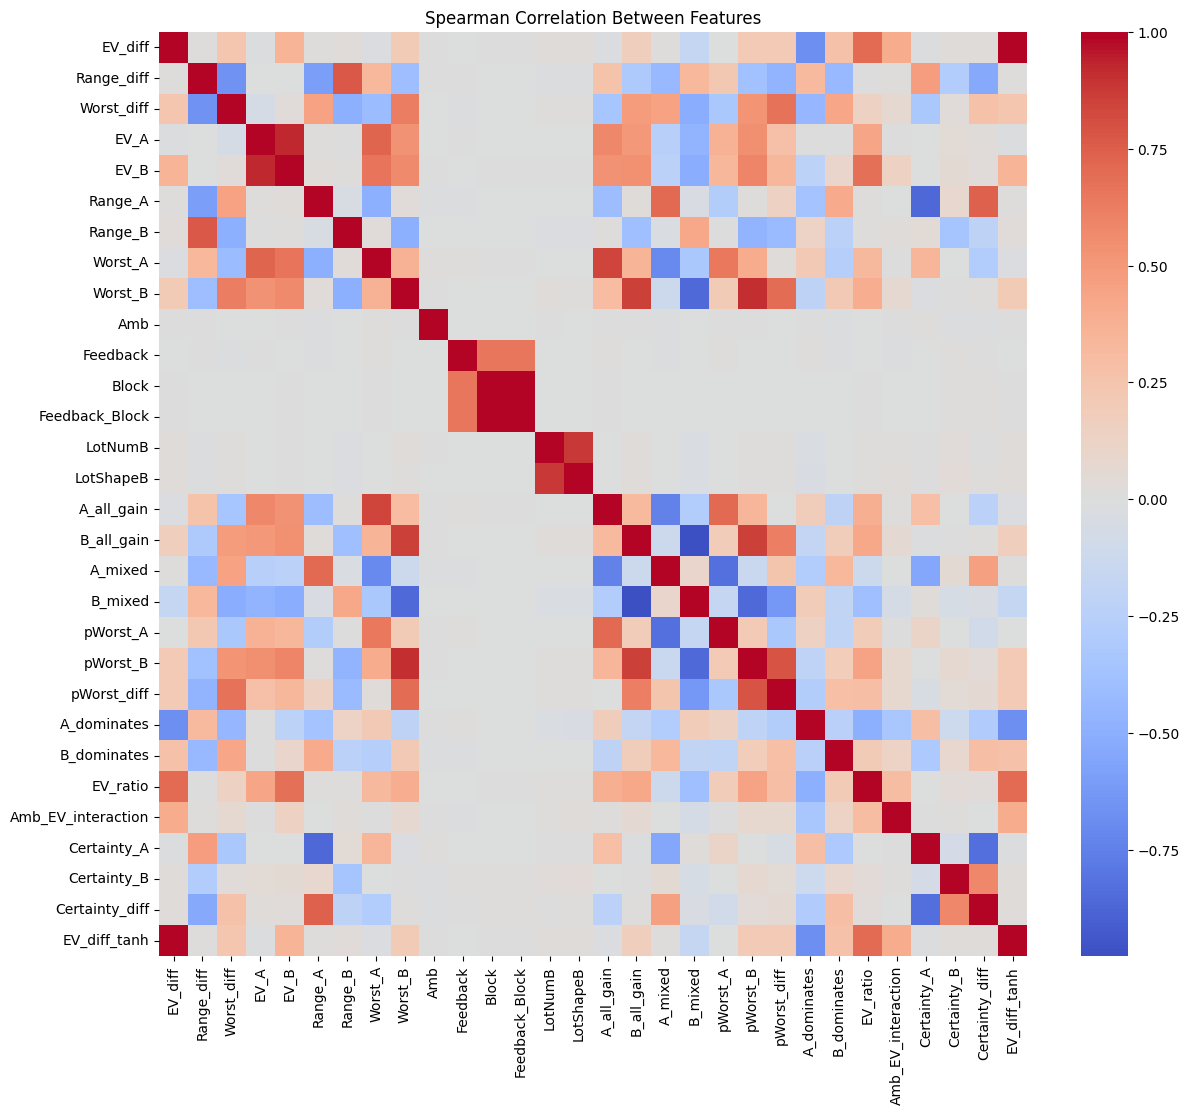

In [73]:
plot_feature_correlation(X_new, X_new.columns)

In [80]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

def permutation_importance_cv(model, X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    importances = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        result = permutation_importance(
            model,
            X_val,
            y_val,
            scoring="neg_mean_absolute_error",
            n_repeats=10,
            random_state=42
        )
        importances.append(result.importances_mean)

    return pd.Series(
        np.mean(importances, axis=0),
        index=X.columns
    ).sort_values(ascending=False)


# Feature selection after evalutation

In [91]:
DROP = [
    "Feedback_Block",
    "Block",
    "Certainty_A",
    "Certainty_diff",
    "A_mixed",
    "B_mixed",
    "B_all_gain",
    "B_dominates",
    "EV_B",
    "EV_ratio",
    "Worst_A",
    "pWorst_A",
    "pWorst_diff",
    "Range_diff"
]


In [94]:
X_new = X_new.drop(columns=[c for c in DROP if c in X_new.columns])

In [105]:
import numpy as np

# --- Variance A ---
ev_A = X_new["EV_A"]
X_new["Var_A"] = (
    X["pHa"] * (X["Ha"] - ev_A) ** 2 +
    (1 - X["pHa"]) * (X["La"] - ev_A) ** 2
)

# --- Variance B ---
X_new["Var_B"] = X["B"].apply(
    lambda lot: np.sum(
        np.array([p for p, _ in lot]) *
        (np.array([x for _, x in lot]) -
         np.sum(np.array([p for p, _ in lot]) *
                np.array([x for _, x in lot]))) ** 2
    )
)

X_new["Var_diff"] = X_new["Var_A"] - X_new["Var_B"]


In [107]:
# --- Skewness B (proxy, not normalized) ---
X_new["Skew_B"] = X["B"].apply(
    lambda lot: np.sum(
        np.array([p for p, _ in lot]) *
        (np.array([x for _, x in lot]) -
         np.sum(np.array([p for p, _ in lot]) *
                np.array([x for _, x in lot]))) ** 3
    )
)


In [108]:
# --- Extremes ---
X_new["Max_A"] = X[["Ha", "La"]].max(axis=1)
X_new["Min_A"] = X[["Ha", "La"]].min(axis=1)

X_new["Max_B"] = X["B"].apply(lambda lot: max(x for _, x in lot))
X_new["Min_B"] = X["B"].apply(lambda lot: min(x for _, x in lot))

# --- Regret features ---
X_new["Regret_A"] = X_new["Max_B"] - X_new["Min_A"]
X_new["Regret_B"] = X_new["Max_A"] - X_new["Min_B"]
X_new["Regret_diff"] = X_new["Regret_A"] - X_new["Regret_B"]


## RF regression using XGBOOST

In [74]:
X_xgb = X_rf.copy()
y = feature_table["bRate"].copy()


In [75]:
from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_xgb,
    y,
    test_size=0.2,
    random_state=42
)


In [76]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=4,          
    verbosity=1
)

xgb.fit(X_train_rf, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_xgb = xgb.predict(X_test_rf)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGB Test MAE:  {mae:.4f}")
print(f"XGB Test RMSE: {rmse:.4f}")
print(f"XGB Test R²:   {r2:.4f}")


XGB Test MAE:  0.0803
XGB Test RMSE: 0.1025
XGB Test R²:   0.7855


In [78]:
from sklearn.model_selection import cross_val_score

cv_mae = -cross_val_score(
    xgb,
    X_xgb,
    y,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=1  
)

print(f"XGB CV MAE: mean={cv_mae.mean():.4f}, std={cv_mae.std():.4f}")


XGB CV MAE: mean=0.0821, std=0.0010


In [35]:
import pandas as pd

xgb_importance = (
    pd.Series(xgb.feature_importances_, index=X_xgb.columns)
      .sort_values(ascending=False)
)

xgb_importance.head(15)


EV_diff       0.262407
Amb           0.083582
Worst_diff    0.081262
Worst_A       0.073309
Range_A       0.067749
Worst_B       0.065830
Range_B       0.061831
EV_A          0.061566
LotNumB       0.052233
LotShapeB     0.050483
Range_diff    0.042927
EV_B          0.040168
Feedback      0.019536
Corr          0.013192
Block         0.012526
dtype: float32

In [36]:
import pandas as pd


booster = xgb.get_booster()

gain = booster.get_score(importance_type="gain")

gain_imp = (pd.Series(gain, name="gain")
            .sort_values(ascending=False)
            .reset_index()
            .rename(columns={"index": "feature"}))

print(gain_imp.head(20))


           feature      gain
0          EV_diff  0.604999
1              Amb  0.192705
2       Worst_diff  0.187354
3          Worst_A  0.169019
4          Range_A  0.156200
5          Worst_B  0.151775
6          Range_B  0.142556
7             EV_A  0.141945
8          LotNumB  0.120428
9        LotShapeB  0.116392
10      Range_diff  0.098971
11            EV_B  0.092611
12        Feedback  0.045042
13            Corr  0.030416
14           Block  0.028880
15  Feedback_Block  0.026279


In [37]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, make_scorer

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

perm = permutation_importance(
    xgb,
    X_test_rf,
    y_test,
    scoring=mae_scorer,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_imp = (
    pd.DataFrame({
        "feature": X_test_rf.columns,
        "mae_increase": -perm.importances_mean,  # flip sign
        "std": perm.importances_std
    })
    .sort_values("mae_increase", ascending=False)
)

perm_imp.head(15)


,feature,mae_increase,std
11,Block,0.000039,0.000095
13,Corr,0.000018,0.000029
12,Feedback_Block,-0.000003,0.000027
10,Feedback,-0.000970,0.000130
15,LotShapeB,-0.002272,0.000307
4,EV_B,-0.002943,0.000380
14,LotNumB,-0.005567,0.000281
9,Amb,-0.008947,0.000471
7,Worst_A,-0.011279,0.000755
1,Range_diff,-0.011587,0.000768


Changing the feature table

In [12]:
from xgboost import XGBRegressor

In [27]:
X_changed = X_rf.copy()

In [28]:
X_changed = X_changed.drop(
    columns=["Feedback", "Block"]
)

In [29]:
X_new = X_changed.copy()

In [31]:
import numpy as np

In [32]:
X_new["A_all_gain"] = (X_new["Worst_A"] >= 0).astype(int)
X_new["B_all_gain"] = (X_new["Worst_B"] >= 0).astype(int)

X_new["A_mixed"] = ((X_new["Worst_A"] < 0) & (X_new["Range_A"] > 0)).astype(int)
X_new["B_mixed"] = ((X_new["Worst_B"] < 0) & (X_new["Range_B"] > 0)).astype(int)
X_new["pWorst_A"] = X_new["Worst_A"] * (1 - choices["pHa"])
X_new["pWorst_B"] = X_new["Worst_B"] * (1 - choices["pHb"])

X_new["pWorst_diff"] = X_new["pWorst_B"] - X_new["pWorst_A"]
X_new["A_dominates"] = (
    (X_new["EV_A"] > X_new["EV_B"]) &
    (X_new["Worst_A"] >= X_new["Worst_B"]) &
    (X_new["Range_A"] <= X_new["Range_B"])
).astype(int)

X_new["B_dominates"] = (
    (X_new["EV_B"] > X_new["EV_A"]) &
    (X_new["Worst_B"] >= X_new["Worst_A"]) &
    (X_new["Range_B"] <= X_new["Range_A"])
).astype(int)

X_new["EV_ratio"] = X_new["EV_B"] / (X_new["EV_A"].abs() + 1e-6)
X_new["Amb_EV_interaction"] = X_new["Amb"] * X_new["EV_diff"]
X_new["Certainty_A"] = (choices["pHa"] > 0.8).astype(int)
X_new["Certainty_B"] = (choices["pHb"] > 0.8).astype(int)

X_new["Certainty_diff"] = X_new["Certainty_B"] - X_new["Certainty_A"]
X_new["EV_diff_tanh"] = np.tanh(X_new["EV_diff"] / 10)



In [33]:
drop_cols = [
    "Corr",
    "B_dominates",
    "B_mixed",
    "A_mixed",
    "B_all_gain",
    "Certainty_A"
]

X_new = X_new.drop(columns=[c for c in drop_cols if c in X.columns])


In [ ]:
# X_changed = X_changed.drop(
#     columns=["Feedback", "Feedback_Block", "Block", "Corr"]
# )

In [34]:
y = feature_table["bRate"].copy()

In [110]:
from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42
)


In [111]:
from xgboost import XGBRegressor

xgb_changed = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    # objective="reg:logistic",
    # objective="reg:squarederror",
    objective="reg:squaredlogerror",
    # objective="reg:absoluteerror",
    # objective="reg:pseudohubererror",
    # objective="binary:logistic",
    # objective="binary:logitraw",
    random_state=42,
    n_jobs=4,          
    verbosity=1
)

xgb_changed.fit(X_train_rf, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squaredlogerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabet

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_xgb = xgb_changed.predict(X_test_rf)

## if logit_raw
# y_pred_xgb = 1 / (1 + np.exp(-y_pred_xgb))

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGB Test MAE:  {mae:.4f}")
print(f"XGB Test RMSE: {rmse:.4f}")
print(f"XGB Test R²:   {r2:.4f}")


XGB Test MAE:  0.0751
XGB Test RMSE: 0.0958
XGB Test R²:   0.8126


In [113]:
from sklearn.model_selection import cross_val_score

cv_mae_xgb = -cross_val_score(
    xgb_changed,
    X_new,
    y,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=1   
)

print(f"XGB CV MAE: mean={cv_mae_xgb.mean():.4f}, std={cv_mae_xgb.std():.4f}")


XGB CV MAE: mean=0.0768, std=0.0018


In [114]:
permutation_importance_cv(xgb_changed, X_new, y, n_splits=5)

EV_diff               0.057062
Regret_A              0.011329
EV_diff_tanh          0.009216
Regret_B              0.008302
Min_A                 0.006046
Amb                   0.006045
EV_A                  0.004753
LotNumB               0.004221
Skew_B                0.003849
Max_A                 0.003263
Var_diff              0.003223
pWorst_B              0.003058
Worst_diff            0.003018
Max_B                 0.002889
Var_B                 0.002796
Feedback              0.002637
Regret_diff           0.002528
Min_B                 0.001939
Worst_B               0.001658
Var_A                 0.001646
Amb_EV_interaction    0.001594
Range_A               0.000854
A_all_gain            0.000553
LotShapeB             0.000482
Range_B               0.000357
A_dominates           0.000261
Certainty_B           0.000177
dtype: float64

In [131]:
import pandas as pd


booster = xgb_changed.get_booster()

gain = booster.get_score(importance_type="gain")

gain_imp = (pd.Series(gain, name="gain")
            .sort_values(ascending=False)
            .reset_index()
            .rename(columns={"index": "feature"}))

print(gain_imp.head(20))


               feature      gain
0          A_dominates  0.710231
1         EV_diff_tanh  0.560972
2           A_all_gain  0.330126
3              EV_diff  0.190797
4          Certainty_B  0.175721
5           B_all_gain  0.128750
6          Certainty_A  0.098950
7       Certainty_diff  0.078678
8           Worst_diff  0.077171
9                  Amb  0.066336
10             Range_B  0.052629
11           LotShapeB  0.052215
12             Range_A  0.046115
13             LotNumB  0.045526
14                EV_A  0.041996
15             Worst_A  0.041339
16  Amb_EV_interaction  0.039412
17         pWorst_diff  0.038751
18            pWorst_B  0.037902
19            EV_ratio  0.030456


In [132]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, make_scorer

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

perm = permutation_importance(
    xgb_changed,
    X_test_rf,
    y_test,
    scoring=mae_scorer,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_imp = (
    pd.DataFrame({
        "feature": X_test_rf.columns,
        "mae_increase": -perm.importances_mean,  # flip sign
        "std": perm.importances_std
    })
    .sort_values("mae_increase", ascending=False)
)

perm_imp.head(15)


,feature,mae_increase,std
15,A_mixed,-6.465981e-07,0.000013
16,B_mixed,-9.693468e-06,0.000013
21,B_dominates,-5.127114e-05,0.000045
14,B_all_gain,-5.308222e-05,0.000050
13,A_all_gain,-2.722695e-04,0.000057
24,Certainty_A,-4.138861e-04,0.000116
26,Certainty_diff,-6.361037e-04,0.000185
4,EV_B,-1.500695e-03,0.000306
10,Feedback_Block,-1.743096e-03,0.000282
17,pWorst_A,-1.771580e-03,0.000239


## Hyperparameter tuning with optuna on the XBBOOST model

In [45]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [39]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


In [157]:
def objective(trial):
    # params = {
    #     "n_estimators": trial.suggest_int("n_estimators", 1000, 1200),
    #     "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
    #     "max_depth": trial.suggest_int("max_depth", 2, 10),
    #     "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 20.0, log=True),
    #     "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    #     "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    #     "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    #     "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
    #     "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    # }
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 800, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 20.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.8, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.8, 0.8),
        # "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        # "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        # "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    

    model = XGBRegressor(
        **params,
        # objective="reg:squaredlogerror",
        objective="reg:logistic",
        random_state=42,
        n_jobs=1,         
        verbosity=0
    )

    model.fit(X_train_rf, y_train)
    
    y_pred_xgb = model.predict(X_test_rf)
    mae = mean_absolute_error(y_test, y_pred_xgb)


    # cv_mae = -cross_val_score(
    #     model,
    #     X_new,
    #     y,
    #     scoring="neg_mean_absolute_error",
    #     cv=cv,
    #     n_jobs=1
    # ).mean()

    return mae


First parameter ranges

In [ ]:
# import numpy as np
# import optuna
# import xgboost as xgb
# from sklearn.model_selection import KFold
# from sklearn.metrics import mean_absolute_error
# from optuna.samplers import TPESampler

# # Fixed CV splitter for reproducibility
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Build DMatrix once (faster)
# X_np = X_changed.values
# y_np = y.values
# dall = xgb.DMatrix(X_np, label=y_np)

# # Precompute folds (list of (train_idx, valid_idx))
# folds = [(tr, va) for tr, va in kf.split(X_np, y_np)]

# def objective(trial):
#     params = {
#         "verbosity": 0,
#         "objective": "reg:squarederror",
#         "eval_metric": "mae",
#         "tree_method": "hist",
#         "seed": 42,

#         # Smarter search space (focused)
#         "max_depth": trial.suggest_int("max_depth", 2, 8),
#         "eta": trial.suggest_float("eta", 0.01, 0.08, log=True),
#         "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 30.0, log=True),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "gamma": trial.suggest_float("gamma", 0.0, 5.0),
#         "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
#         "lambda": trial.suggest_float("lambda", 1e-3, 30.0, log=True),
#     }

#     num_boost_round = trial.suggest_int("num_boost_round", 500, 3000)

#     # Run CV using xgboost.cv (simple + robust)
#     cv_results = xgb.cv(
#         params=params,
#         dtrain=dall,
#         folds=folds,
#         num_boost_round=num_boost_round,
#         early_stopping_rounds=80,
#         verbose_eval=False
#     )

#     # Min of validation MAE over boosting rounds
#     return float(cv_results["test-mae-mean"].min())


Other parameters

In [ ]:
# import numpy as np
# import optuna
# import xgboost as xgb
# from sklearn.model_selection import KFold
# from sklearn.metrics import mean_absolute_error
# from optuna.samplers import TPESampler

# # Fixed CV splitter for reproducibility
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Build DMatrix once (faster)
# X_np = X_rf.values
# y_np = y.values
# dall = xgb.DMatrix(X_np, label=y_np)

# # Precompute folds (list of (train_idx, valid_idx))
# folds = [(tr, va) for tr, va in kf.split(X_np, y_np)]
# def objective_refine(trial):
#     params = {
#         "verbosity": 0,
#         "objective": "reg:squarederror",
#         "eval_metric": "mae",
#         "tree_method": "hist",
#         "seed": 42,

#         # refine around depth=6
#         "max_depth": trial.suggest_int("max_depth", 4, 7),

#         # refine around eta≈0.021
#         "eta": trial.suggest_float("eta", 0.012, 0.035, log=True),

#         # broaden slightly upward to control overfit
#         "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 8.0, log=True),

#         # keep sampling in good region
#         "subsample": trial.suggest_float("subsample", 0.65, 0.95),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 0.95),

#         # allow gamma to matter more (sometimes helps)
#         "gamma": trial.suggest_float("gamma", 0.0, 0.5),

#         # allow meaningful regularization (your best was ~0)
#         "alpha": trial.suggest_float("alpha", 1e-8, 1e-1, log=True),
#         "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
#     }

#     # keep boosting rounds in the right ballpark, let early stopping decide
#     num_boost_round = trial.suggest_int("num_boost_round", 1200, 3500)

#     cv_results = xgb.cv(
#         params=params,
#         dtrain=dall,
#         folds=folds,
#         num_boost_round=num_boost_round,
#         early_stopping_rounds=80,
#         verbose_eval=False
#     )

#     return float(cv_results["test-mae-mean"].min())


In [158]:
from optuna.samplers import TPESampler

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)

study.optimize(objective, n_trials=300, n_jobs=-1, show_progress_bar=True, timeout = 600)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-02-05 23:34:41,464] A new study created in memory with name: no-name-319f5968-3171-4efc-b755-bc8f38b10c18


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-02-05 23:34:55,771] Trial 3 finished with value: 0.07485098543256306 and parameters: {'n_estimators': 801, 'learning_rate': 0.050742408017716574, 'max_depth': 4, 'min_child_weight': 7.1398943962416705, 'subsample': 0.8, 'colsample_bytree': 0.8}. Best is trial 3 with value: 0.07485098543256306.
[I 2026-02-05 23:34:56,908] Trial 1 finished with value: 0.07493088048423503 and parameters: {'n_estimators': 1414, 'learning_rate': 0.02370354052997173, 'max_depth': 4, 'min_child_weight': 0.05091475199419445, 'subsample': 0.8, 'colsample_bytree': 0.8}. Best is trial 3 with value: 0.07485098543256306.
[I 2026-02-05 23:35:00,845] Trial 4 finished with value: 0.08094392857437675 and parameters: {'n_estimators': 1218, 'learning_rate': 0.1834968430825444, 'max_depth': 5, 'min_child_weight': 0.19144507369973401, 'subsample': 0.8, 'colsample_bytree': 0.8}. Best is trial 3 with value: 0.07485098543256306.
[I 2026-02-05 23:35:01,534] Trial 0 finished with value: 0.0744164525198816 and parameters

In [152]:
best_params = study.best_params

best_xgb = XGBRegressor(
    **best_params,
    objective="reg:logistic",
    random_state=42,
    n_jobs=1,
    verbosity=0
)
best_xgb.fit(X_train_rf, y_train)

y_pred = best_xgb.predict(X_test_rf)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(mae)
print(rmse)
print(r2)

0.07394678200207645
0.09432948242444901
0.8182485694033309


In [153]:
from sklearn.model_selection import cross_validate
from scipy.stats import sem

scores = cross_validate(
    best_xgb,
    X_new,
    y,
    scoring=['r2', 'neg_mean_absolute_error'],
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1   
)

print('r2', np.mean(scores['test_r2']), sem(scores['test_r2']))
print('mean_absolute_error',
      np.mean(-scores['test_neg_mean_absolute_error']),
      sem(-scores['test_neg_mean_absolute_error']))

r2 0.8144331370321973 0.002399790182564618
mean_absolute_error 0.07581884190151518 0.0004993731574631956


## Lets run a different model, where a complete example is in the lectures, LightGBM

In [41]:
from sklearn.model_selection import cross_validate
from scipy.stats import sem

In [29]:
import lightgbm as lgb

lgb_reg = lgb.LGBMRegressor(force_col_wise=True)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_changed,
    y,
    test_size=0.2,
    random_state=42
)


In [44]:
lgb_reg.fit(X_train, y_train)
preds = lgb_reg.predict(X_test)

In [45]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import KFold

SEED = 42

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "l1",              # MAE inside LightGBM
        "boosting_type": "gbdt",
        "verbosity": -1,

        # stability / reproducibility
        "seed": SEED,
        "feature_fraction_seed": SEED,
        "bagging_seed": SEED,

        # core capacity
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),  # couple with leaves
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200),

        # regularization (often big for MAE)
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        # subsampling
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 0, 10),

        # optional: sometimes helps
        "extra_trees": trial.suggest_categorical("extra_trees", [False, True]),
    }

    # many rounds + early stopping finds the right "n_estimators" for you
    num_boost_round = 10000

    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

    pruning_callback = optuna.integration.LightGBMPruningCallback(trial, metric="l1")

    cv_result = lgb.cv(
        params,
        lgb.Dataset(X_changed, label=y),
        folds=cv,
        num_boost_round=num_boost_round,
        callbacks=[
            lgb.early_stopping(stopping_rounds=200, verbose=False),
            pruning_callback
        ],
        stratified=False,
        seed=SEED,
    )

    # LightGBM uses keys like 'valid l1-mean'
    best_mae = np.min(cv_result["valid l1-mean"])
    return best_mae


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=20),
)

study.optimize(objective, n_trials=50)   # 100 is often too small for LGBM spaces

print("Best CV MAE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-02-04 21:44:30,517] A new study created in memory with name: no-name-b3c5c1de-2a67-49a9-b581-dc0031084ccc
c:\Users\Βασιλης\Applied_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:87: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
[I 2026-02-04 21:45:10,094] Trial 0 finished with value: 0.09865453488055707 and parameters: {'learning_rate': 0.014124115025060347, 'num_leaves': 223, 'max_depth': 10, 'min_child_samples': 122, 'min_split_gain': 0.15601864044243652, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'feature_fraction': 0.9330880728874675, 'bagging_fraction': 0.8005575058716043, 'bagging_freq': 7, 'extra_trees': True}. Best is trial 0 with value: 0.09865453488055707.
c:\Users\Βασιλης\Applied_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:87: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
[I 2026-02-04 21:45:26,517] Trial 1 finished with value: 0.10205166708303218 and para

Best CV MAE: 0.0823013441864923
Best params: {'learning_rate': 0.04789475653174698, 'num_leaves': 21, 'max_depth': 6, 'min_child_samples': 111, 'min_split_gain': 0.0023960687840891086, 'reg_alpha': 1.3954395798975662e-07, 'reg_lambda': 0.1930626483822258, 'feature_fraction': 0.69114126909939, 'bagging_fraction': 0.6952301584807367, 'bagging_freq': 5, 'extra_trees': False}


In [46]:
best_params = study.best_params.copy()
best_params.update({
    "objective": "regression",
    "metric": "l1",
    "verbosity": -1,
    "seed": SEED,
})

# run one CV to get best num_boost_round
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_result = lgb.cv(
    best_params,
    lgb.Dataset(X_changed, label=y),
    folds=cv,
    num_boost_round=10000,
    callbacks=[lgb.early_stopping(200, verbose=False)],
    seed=SEED,
)
best_num_boost_round = len(cv_result["valid l1-mean"])

final_model = lgb.LGBMRegressor(**best_params, n_estimators=best_num_boost_round)


c:\Users\Βασιλης\Applied_ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:87: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(


In [32]:
def objective(trial):

    X_train, X_test, y_train, y_test = train_test_split(
        X_changed,
        y,
        test_size=0.2,
        random_state=42
    )

    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_test, label=y_test)

    param = {
        "objective": "regression",
        "metric": "mean_squared_error",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "num_leaves": trial.suggest_int("num_leaves", 40, 80),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 0, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }

    # Add a callback for pruning.
    pruning_callback = optuna.integration.LightGBMPruningCallback(
        trial, metric="l2", valid_name="valid")
    gbm = lgb.train(param, dtrain, valid_sets=[dvalid],
                    valid_names="valid",
                    callbacks=[pruning_callback])

    preds = gbm.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae

In [ ]:
from datetime import datetime
SEED = 42
np.random.seed(SEED)
now = datetime.now()
timestamp_string = now.strftime("%Y-%m-%d %H:%M:%S")

study_name = f"lightGBM-bc-{timestamp_string}" # Unique identifier of the study.

study = optuna.create_study(
    study_name=study_name,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=100, timeout=600)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-02-04 21:33:24,888] A new study created in memory with name: lightGBM-bc-2026-02-04 21:33:24
[I 2026-02-04 21:33:28,189] Trial 0 finished with value: 0.08653448520608188 and parameters: {'num_leaves': 55, 'learning_rate': 0.09556428757689246, 'n_estimators': 1232, 'colsample_bytree': 0.759195090518222, 'subsample': 0.4936111842654619, 'subsample_freq': 1, 'min_child_samples': 10}. Best is trial 0 with value: 0.08653448520608188.
[I 2026-02-04 21:33:31,424] Trial 1 finished with value: 0.08225801670530594 and parameters: {'num_leaves': 75, 'learning_rate': 0.0641003510568888, 'n_estimators': 1208, 'colsample_bytree': 0.41235069657748147, 'subsample': 0.9819459112971965, 'subsample_freq': 9, 'min_child_samples': 25}. Best is trial 1 with value: 0.08225801670530594.
[I 2026-02-04 21:33:33,099] Trial 2 finished with value: 0.08003012364162883 and parameters: {'num_leaves': 47, 'learning_rate': 0.026506405886809047, 'n_estimators': 804, 'colsample_bytree': 0.7148538589793427, 'subsa

Best MAE: 0.07995402566836263
Best params: {'num_leaves': 45, 'learning_rate': 0.03629301836816964, 'n_estimators': 866, 'colsample_bytree': 0.6736419905302216, 'subsample': 0.8711055768358081, 'subsample_freq': 2, 'min_child_samples': 54}


In [47]:
print('Number of finished trials: ', len(study.trials))
print('Best trial:')
best_trial = study.best_trial

print('Mae: ', best_trial.value)
print('Params: ', study.best_params)

Number of finished trials:  50
Best trial:
Mae:  0.0823013441864923
Params:  {'learning_rate': 0.04789475653174698, 'num_leaves': 21, 'max_depth': 6, 'min_child_samples': 111, 'min_split_gain': 0.0023960687840891086, 'reg_alpha': 1.3954395798975662e-07, 'reg_lambda': 0.1930626483822258, 'feature_fraction': 0.69114126909939, 'bagging_fraction': 0.6952301584807367, 'bagging_freq': 5, 'extra_trees': False}


In [48]:
gbm = lgb.LGBMRegressor(**best_trial.params)
scores = cross_validate(
    gbm,
    X_changed,
    y,
    scoring=['r2', 'neg_mean_absolute_error'],
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1   
)

print('r2', np.mean(scores['test_r2']), sem(scores['test_r2']))
print('MAE',
      np.mean(-scores['test_neg_mean_absolute_error']),
      sem(-scores['test_neg_mean_absolute_error'])
)

r2 0.744122057031244 0.0022885209425129575
MAE 0.08888314869171762 0.0005621348516112451


In [ ]:
lgb_reg.fit(X_train, y_train)
preds = lgb_reg.predict(X_test)

[LightGBM] [Info] Total Bins 1591
[LightGBM] [Info] Number of data points in the train set: 11654, number of used features: 14
[LightGBM] [Info] Start training from score 0.518642


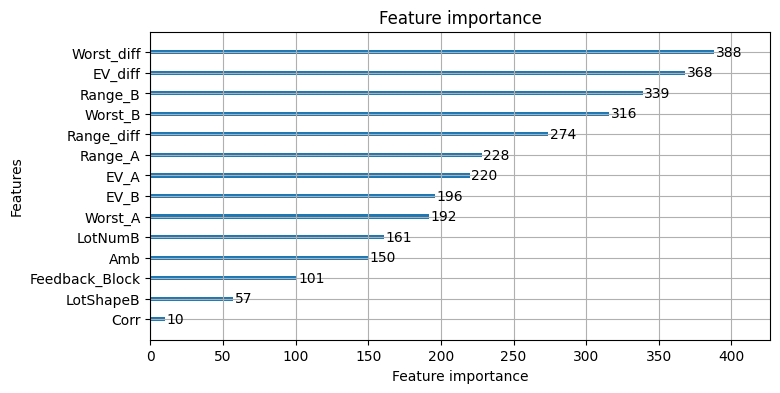

In [56]:
lgb_reg = lgb.LGBMRegressor(force_col_wise=True)
lgb_reg.fit(X_train, y_train)
_ = lgb.plot_importance(lgb_reg, figsize=(8, 4))

In [97]:
X_new = X_changed.copy()

In [ ]:
X_new["A_all_gain"] = (X_new["Worst_A"] >= 0).astype(int)
X_new["B_all_gain"] = (X_new["Worst_B"] >= 0).astype(int)

X_new["A_mixed"] = ((X_new["Worst_A"] < 0) & (X_new["Range_A"] > 0)).astype(int)
X_new["B_mixed"] = ((X_new["Worst_B"] < 0) & (X_new["Range_B"] > 0)).astype(int)
X_new["pWorst_A"] = X_new["Worst_A"] * (1 - choices["pHa"])
X_new["pWorst_B"] = X_new["Worst_B"] * (1 - choices["pHb"])

X_new["pWorst_diff"] = X_new["pWorst_B"] - X_new["pWorst_A"]
X_new["A_dominates"] = (
    (X_new["EV_A"] > X_new["EV_B"]) &
    (X_new["Worst_A"] >= X_new["Worst_B"]) &
    (X_new["Range_A"] <= X_new["Range_B"])
).astype(int)

X_new["B_dominates"] = (
    (X_new["EV_B"] > X_new["EV_A"]) &
    (X_new["Worst_B"] >= X_new["Worst_A"]) &
    (X_new["Range_B"] <= X_new["Range_A"])
).astype(int)

X_new["EV_ratio"] = X_new["EV_B"] / (X_new["EV_A"].abs() + 1e-6)
X_new["Amb_EV_interaction"] = X_new["Amb"] * X_new["EV_diff"]
X_new["Certainty_A"] = (choices["pHa"] > 0.8).astype(int)
X_new["Certainty_B"] = (choices["pHb"] > 0.8).astype(int)

X_new["Certainty_diff"] = X_new["Certainty_B"] - X_new["Certainty_A"]
X_new["EV_diff_tanh"] = np.tanh(X_new["EV_diff"] / 10)



In [107]:
X_copy = X_new.copy()

In [108]:
drop_cols = [
    "Corr",
    "B_dominates",
    "B_mixed",
    "A_mixed",
    "B_all_gain",
    "Certainty_A"
]

X_new = X_new.drop(columns=[c for c in drop_cols if c in X.columns])


In [126]:
from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import KFold

SEED = 42

def objective(trial):

    params = {
        "objective": "regression",
        # "objective": "huber",
        "metric": "mae",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": SEED,
        "alpha": 0.9,

        # core
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        # "max_depth": trial.suggest_int("max_depth", 8, 8),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        #  "min_child_samples": trial.suggest_int("min_child_samples", 60, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),

        "n_estimators": trial.suggest_int("n_estimators", 50, 300),

        # regularization (important for MAE)
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        # subsampling
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 0, 10),

        # sometimes helps
        "extra_trees": trial.suggest_categorical("extra_trees", [False, True]),
    }
    
    dtrain = lgb.Dataset(X_train_rf, label=y_train)
    dvalid = lgb.Dataset(X_test_rf, label=y_test)


    pruning_cb = optuna.integration.LightGBMPruningCallback(trial, "l1", valid_name="valid")
    
    gbm = lgb.train(params, dtrain, valid_sets=[dvalid],
                    valid_names="valid",
                    callbacks=[pruning_cb])

    preds = gbm.predict(X_test_rf)
    mae = mean_absolute_error(y_test, preds)
    return mae
    # cv_result = lgb.cv(
    #     params,
    #     lgb.Dataset(X_new, label=y),
    #     folds=cv,
    #     num_boost_round=5000,
    #     callbacks=[
    #         lgb.early_stopping(200, verbose=False),
    #         pruning_cb
    #     ],
    #     seed=SEED
    # )

    # return np.min(cv_result["valid l1-mean"])


In [ ]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=40)
)

study.optimize(
    objective,
    n_trials=1000,
    timeout=600   # 10 minutes
)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-02-05 22:51:56,906] A new study created in memory with name: no-name-64a2b2d4-7a41-4d6f-bb0d-b5d400ce8f5d


[I 2026-02-05 22:51:58,050] Trial 0 finished with value: 0.10093590002110639 and parameters: {'learning_rate': 0.014124115025060347, 'num_leaves': 123, 'max_depth': 8, 'min_child_samples': 62, 'n_estimators': 89, 'min_split_gain': 0.15599452033620265, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'feature_fraction': 0.8404460046972835, 'bagging_fraction': 0.8832290311184181, 'bagging_freq': 0, 'extra_trees': False}. Best is trial 0 with value: 0.10093590002110639.
[I 2026-02-05 22:51:58,611] Trial 1 finished with value: 0.12160239321852187 and parameters: {'learning_rate': 0.009008485225328879, 'num_leaves': 36, 'max_depth': 3, 'min_child_samples': 34, 'n_estimators': 181, 'min_split_gain': 0.43194501864211576, 'reg_alpha': 4.17890272377219e-06, 'reg_lambda': 0.0032112643094417484, 'feature_fraction': 0.6557975442608167, 'bagging_fraction': 0.7168578594140873, 'bagging_freq': 4, 'extra_trees': True}. Best is trial 0 with value: 0.10093590002110639.
[I 2026-02-0

Best CV MAE: 0.07452370850415826
Best params: {'learning_rate': 0.07487860740758583, 'num_leaves': 81, 'max_depth': 8, 'min_child_samples': 44, 'n_estimators': 228, 'min_split_gain': 0.00020586142386927215, 'reg_alpha': 2.196989773720499e-05, 'reg_lambda': 0.00026776637423863705, 'feature_fraction': 0.7018459124568617, 'bagging_fraction': 0.8179306941543114, 'bagging_freq': 1, 'extra_trees': False}


In [142]:
print('Number of finished trials: ', len(study.trials))
print('Best trial:')
best_trial = study.best_trial

print('Mae: ', best_trial.value)
print('Params: ', study.best_params)

Number of finished trials:  1000
Best trial:
Mae:  0.07452370850415826
Params:  {'learning_rate': 0.07487860740758583, 'num_leaves': 81, 'max_depth': 8, 'min_child_samples': 44, 'n_estimators': 228, 'min_split_gain': 0.00020586142386927215, 'reg_alpha': 2.196989773720499e-05, 'reg_lambda': 0.00026776637423863705, 'feature_fraction': 0.7018459124568617, 'bagging_fraction': 0.8179306941543114, 'bagging_freq': 1, 'extra_trees': False}


In [147]:

best_lgb = lgb.LGBMRegressor(
    **best_trial.params
)


best_lgb.fit(X_train_rf, y_train)

y_pred = best_lgb.predict(X_test_rf)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(mae)
print(rmse)
print(r2)


0.07528646068756938
0.0959625497366412
0.8119009975613746


In [148]:
scores = cross_validate(
    best_lgb,
    X_new,
    y,
    scoring=['r2', 'neg_mean_absolute_error'],
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)

print('r2', np.mean(scores['test_r2']), sem(scores['test_r2']))
print('MAE',
      np.mean(-scores['test_neg_mean_absolute_error']),
      sem(-scores['test_neg_mean_absolute_error'])
)

r2 0.8097785637689491 0.0023811511215918297
MAE 0.07665615794672197 0.00046544424712650456


In [149]:
import shap

explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_new)

shap_importance = np.abs(shap_values).mean(axis=0)
imp = pd.Series(shap_importance, index=X_new.columns).sort_values()

imp


Certainty_B           0.001218
Feedback              0.004129
Range_B               0.004511
Range_A               0.004683
A_dominates           0.005171
Amb_EV_interaction    0.005368
LotShapeB             0.006100
Worst_B               0.006964
Skew_B                0.007226
Max_B                 0.008342
Var_diff              0.008524
A_all_gain            0.008866
Var_B                 0.009069
Var_A                 0.009444
Min_B                 0.010698
Amb                   0.010864
Max_A                 0.011515
pWorst_B              0.011971
Regret_diff           0.012304
Worst_diff            0.012726
EV_A                  0.013016
LotNumB               0.014672
EV_diff_tanh          0.018933
Min_A                 0.019538
Regret_B              0.020688
Regret_A              0.021401
EV_diff               0.091372
dtype: float64